In [201]:
import pandas as pd
import numpy as np

In [202]:
df = pd.read_csv('Admission_Predict.csv', index_col=0)
df

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76
3,316,104,3,3.0,3.5,8.00,1,0.72
4,322,110,3,3.5,2.5,8.67,1,0.80
5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...
396,324,110,3,3.5,3.5,9.04,1,0.82
397,325,107,3,3.0,3.5,9.11,1,0.84
398,330,116,4,5.0,4.5,9.45,1,0.91


In [203]:
df.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76
3,316,104,3,3.0,3.5,8.00,1,0.72
4,322,110,3,3.5,2.5,8.67,1,0.80
5,314,103,2,2.0,3.0,8.21,0,0.65


In [204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 400 entries, 1 to 400
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          400 non-null    int64  
 1   TOEFL Score        400 non-null    int64  
 2   University Rating  400 non-null    int64  
 3   SOP                400 non-null    float64
 4   LOR                400 non-null    float64
 5   CGPA               400 non-null    float64
 6   Research           400 non-null    int64  
 7   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 28.1 KB


In [205]:
df.describe()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


In [206]:
df.isnull().sum()

,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


In [207]:
df['Admitted'] = df['Chance of Admit'] >= 0.75

In [208]:
df = df.drop(['Chance of Admit'], axis=1)
df

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Admitted
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,True
2,324,107,4,4.0,4.5,8.87,1,True
3,316,104,3,3.0,3.5,8.00,1,False
4,322,110,3,3.5,2.5,8.67,1,True
5,314,103,2,2.0,3.0,8.21,0,False
...,...,...,...,...,...,...,...,...
396,324,110,3,3.5,3.5,9.04,1,True
397,325,107,3,3.0,3.5,9.11,1,True
398,330,116,4,5.0,4.5,9.45,1,True


In [209]:
feat = df.drop(['Admitted'], axis=1)
lab = df['Admitted']

In [210]:
feat

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
Serial No.,,,,,,,
1,337,118,4,4.5,4.5,9.65,1
2,324,107,4,4.0,4.5,8.87,1
3,316,104,3,3.0,3.5,8.00,1
4,322,110,3,3.5,2.5,8.67,1
5,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
396,324,110,3,3.5,3.5,9.04,1
397,325,107,3,3.0,3.5,9.11,1
398,330,116,4,5.0,4.5,9.45,1


In [211]:
lab

,Admitted
Serial No.,
1,True
2,True
3,False
4,True
5,False
...,...
396,True
397,True
398,True


In [212]:
from sklearn.preprocessing import PolynomialFeatures
X = df.drop(['Admitted'], axis=1)
y = df['Admitted']
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

In [213]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = dt.predict(X_test)

In [214]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[69  5]
 [ 3 43]]


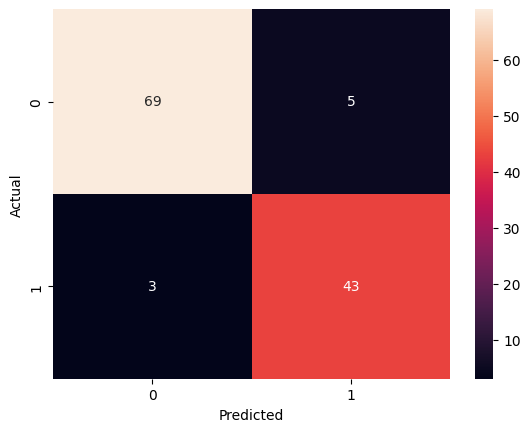

In [215]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [216]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.96      0.93      0.95        74
        True       0.90      0.93      0.91        46

    accuracy                           0.93       120
   macro avg       0.93      0.93      0.93       120
weighted avg       0.93      0.93      0.93       120



In [217]:
from sklearn.tree import DecisionTreeClassifier

dt_gini = DecisionTreeClassifier(criterion='gini')
dt_gini.fit(X_poly, y)

print("Train Accuracy (Gini):", dt_gini.score(X_poly, y))

Train Accuracy (Gini): 1.0


In [218]:
dt_entropy = DecisionTreeClassifier(criterion='entropy')
dt_entropy.fit(X_poly, y)

print("Train Accuracy (Entropy):", dt_entropy.score(X_poly, y))

Train Accuracy (Entropy): 1.0


In [198]:
from sklearn.model_selection import cross_val_score

dt_fixed = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    min_samples_leaf=25,
    min_samples_split=40
)

scores = cross_val_score(dt, feat, lab, cv=5)

print("Cross Validation Scores:", scores)
print("Mean Accuracy:", scores.mean())


Cross Validation Scores: [0.8125 0.75   0.8125 0.775  0.8   ]
Mean Accuracy: 0.79


In [199]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.3, random_state=42)

dt = DecisionTreeClassifier(criterion='entropy')
dt.fit(X_train, y_train)

print("Train Accuracy:", dt.score(X_train, y_train))
print("Test Accuracy:", dt.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.9333333333333333
